In [47]:
import numpy as np
import torch
import torch.nn as nn
import jax
import jax.numpy as jnp
from typing import Optional, Dict, Any

import ftlelab as fl
# import ftlelab.configs as cfg
import ftlelab.models as fmods
import torch

import ftlelab.utils as utils
import ftlelab.data as datasets
import ftlelab.training as training

import jax
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
from ftlelab.ftle.jax_transfer import pytorch_dense_to_jax_params
from ftlelab.ftle.jax_core import ftle_field_batched
# jax.config.update("jax_enable_x64", True)
import ftlelab.ftle as ftle

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


%load_ext autoreload
%autoreload 2

# your JAX FTLE utilities
# adjust import paths to your package layout
from ftlelab.ftle.jax_transfer import pytorch_dense_to_jax_params
from ftlelab.ftle.jax_core import ftle_field_batched

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
def make_eval_grid_np(
    xmin: float = -1.5,
    xmax: float = 1.5,
    ymin: float = -1.5,
    ymax: float = 1.5,
    nx: int = 200,
    ny: int = 200,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns
    -------
    X_grid : (nx*ny, 2) numpy array
    XX, YY : (ny, nx) meshgrids for plotting
    """
    xs = np.linspace(xmin, xmax, nx, dtype=np.float32)
    ys = np.linspace(ymin, ymax, ny, dtype=np.float32)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")
    X_grid = np.column_stack([XX.reshape(-1), YY.reshape(-1)]).astype(np.float32)
    return X_grid, XX, YY


def train_with_jax_ftle_history(
    model: nn.Module,
    train_loader,
    optimizer: torch.optim.Optimizer,
    criterion,
    epochs: int,
    *,
    device: Optional[str] = None,
    hidden_depth: int = 5,
    activation: str = "tanh",
    output_activation: str = "tanh",
    model_type: str = "dense",
    ftle_every: int = 1,
    nx: int = 200,
    ny: int = 200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    ftle_batch_size: int = 1024,
    ftle_dtype: str = "float32",    # "float32" or "float64"
    exact_if_dim_le: int = 4,
    max_steps: int = 50,
    tol: float = 1e-6,
    reshape_fields: bool = True,
    enable_x64: bool = False,
    verbose: bool = True,
):
    """
    Train a PyTorch model and compute JAX-based FTLE fields after each epoch.

    Returns
    -------
    ftle_history : dict
        {
            "layer-1": [field_e1, field_e2, ...],
            ...
            "layer-5": [...],
            "output":  [...]
        }

        Each field is:
        - (ny, nx) np.ndarray if reshape_fields=True
        - (nx*ny,) np.ndarray if reshape_fields=False

    train_history : dict
        {
            "train_loss": [...]
        }

    grid_meta : dict
        {
            "X_grid": (N,2) numpy array,
            "XX": (ny,nx) numpy array,
            "YY": (ny,nx) numpy array,
            "extent": tuple,
            "nx": int,
            "ny": int,
        }
    """
    if device is None:
        device = next(model.parameters()).device
    else:
        device = torch.device(device)
        model.to(device)

    # Set once before first JAX call
    jax.config.update("jax_enable_x64", enable_x64)

    X_grid_np, XX, YY = make_eval_grid_np(
        xmin=extent[0], xmax=extent[1],
        ymin=extent[2], ymax=extent[3],
        nx=nx, ny=ny,
    )

    ftle_history = {f"layer-{k}": [] for k in range(1, hidden_depth + 1)}
    ftle_history["output"] = []
    train_history = {"train_loss": []}

    for epoch in range(epochs):
        # ---------------- train one epoch ----------------
        model.train()
        running_loss = 0.0
        total = 0

        for batch in train_loader:
            if not isinstance(batch, (tuple, list)) or len(batch) != 2:
                raise ValueError("Expected train_loader to yield (x, y).")

            x, y = batch
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            running_loss += loss.item() * bs
            total += bs

        epoch_loss = running_loss / max(total, 1)
        train_history["train_loss"].append(epoch_loss)

        # ---------------- JAX FTLE snapshot ----------------
        if (epoch + 1) % ftle_every == 0:
            model.eval()

            # convert current PyTorch weights -> JAX params
            jax_params = pytorch_dense_to_jax_params(model)

            # hidden layers
            for k in range(1, hidden_depth + 1):
                lam = ftle_field_batched(
                    model_type=model_type,
                    params=jax_params,
                    X_np=X_grid_np,
                    layer_spec=("hidden_k", k),
                    time_L=k,
                    batch_size=ftle_batch_size,
                    activation=activation,
                    output_activation=output_activation,
                    exact_if_dim_le=exact_if_dim_le,
                    max_steps=max_steps,
                    tol=tol,
                    dtype=ftle_dtype,
                )

                if reshape_fields:
                    lam = lam.reshape(ny, nx)

                ftle_history[f"layer-{k}"].append(lam.copy())

            # output layer
            lam_out = ftle_field_batched(
                model_type=model_type,
                params=jax_params,
                X_np=X_grid_np,
                layer_spec="output",
                time_L=hidden_depth + 1,
                batch_size=ftle_batch_size,
                activation=activation,
                output_activation=output_activation,
                exact_if_dim_le=exact_if_dim_le,
                max_steps=max_steps,
                tol=tol,
                dtype=ftle_dtype,
            )

            if reshape_fields:
                lam_out = lam_out.reshape(ny, nx)

            ftle_history["output"].append(lam_out.copy())

        if verbose:
            msg = f"Epoch {epoch + 1}/{epochs} | train_loss = {epoch_loss:.6f}"
            if (epoch + 1) % ftle_every == 0:
                msg += " | JAX FTLE saved"
            print(msg)

    grid_meta = {
        "X_grid": X_grid_np,
        "XX": XX,
        "YY": YY,
        "extent": extent,
        "nx": nx,
        "ny": ny,
    }

    return ftle_history, train_history, grid_meta

In [49]:
total_size = 15000
train_size = int(0.8 * total_size)

In [50]:
batch_size=256

In [53]:
X_circ, y_circ = datasets.make_circle_dataset(num_samples=total_size,
                                              noise_std=0.0,
                                              seed=42)

data_circ = datasets.make_dataloaders(datasets.split_dataset(X_circ, y_circ, seed=42), batch_size=batch_size)

tensor(-7500.)

In [39]:
### Moons
X_moons, y_moons = datasets.make_moons_dataset(num_samples=total_size,
                                               noise_std=0.0,
                                               seed=42)
data_moons = datasets.make_dataloaders(datasets.split_dataset(X_moons, y_moons, seed=42), batch_size=batch_size)

### Spirals
X_spiral, y_spiral = datasets.make_spiral_dataset(num_samples=total_size,
                                                  noise_std=0.0,
                                                  seed=42)
data_spiral = datasets.make_dataloaders(datasets.split_dataset(X_spiral, y_spiral, seed=42), batch_size=batch_size)

### Xor
X_xor, y_xor = datasets.make_xor_dataset(num_samples=total_size,
                                         noise_std=0.0,
                                         seed=42)
data_xor = datasets.make_dataloaders(datasets.split_dataset(X_xor, y_xor, seed=42), batch_size=batch_size)

In [61]:
import torch
import torch.nn as nn

# Example: 5 hidden layers
model = fmods.DenseNet(
    layer_dims=[2] + 12 * [10] + [1],
    activation="tanh",
    output_activation="tanh",
    init_method="paper",
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-2,
    momentum=0.0,
    weight_decay=0.0,
)

criterion = nn.MSELoss()

ftle_history, train_history, grid_meta = train_with_jax_ftle_history(
    model=model,
    train_loader=data_circ["train"],   # must yield (x, y)
    optimizer=optimizer,
    criterion=criterion,
    epochs=200,
    device=device,
    hidden_depth=12,
    activation="tanh",
    output_activation="tanh",
    model_type="dense",
    ftle_every=5,
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    ftle_batch_size=1024,
    ftle_dtype="float32",
    exact_if_dim_le=4,
    max_steps=30,
    tol=1e-6,
    reshape_fields=True,
    enable_x64=False,
    verbose=True,
)

# Access examples:
# ftle_history["layer-1"][0]   -> epoch 1, hidden layer 1
# ftle_history["layer-5"][19]  -> epoch 20, hidden layer 5
# ftle_history["output"][-1]   -> last epoch, output layer

Epoch 1/200 | train_loss = 0.998663
Epoch 2/200 | train_loss = 0.986656
Epoch 3/200 | train_loss = 0.967407
Epoch 4/200 | train_loss = 0.927490


FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

...

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 200/200 | train_loss = 0.021115 | JAX FTLE saved


In [62]:
experiment_name = "8-ftle-per-epoch"

In [63]:
np.save(f"experiment_{experiment_name}/10x12/ftle_history.npy", ftle_history)

In [66]:
ftle_history.keys()

dict_keys(['layer-1', 'layer-2', 'layer-3', 'layer-4', 'layer-5', 'layer-6', 'layer-7', 'layer-8', 'layer-9', 'layer-10', 'layer-11', 'layer-12', 'output'])

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


def plot_ftle_fields_1x6(
    ftle_history,
    epoch_idx=0,                  # index in the saved history, not raw epoch number
    actual_epoch=None,            # e.g. 5, 10, 15, ...
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    cmap="RdBu_r",
    vmin=-4.0,
    vcenter=0.0,
    vmax=4.0,
    multiply_titles_by_L=False,
    figsize=(48, 4.5),
    dpi=160,
):
    layer_keys = [f"layer-{i+1}" for i in range(12)] + ["output"]

    fig, axes = plt.subplots(
        1, 13,
        figsize=figsize,
        dpi=dpi,
        # constrained_layout=True
    )

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    im = None

    for i, key in enumerate(layer_keys):
        ax = axes[i]
        field = np.asarray(ftle_history[key][epoch_idx])

        if field.ndim == 1:
            field = field.reshape(ny, nx)

        im = ax.imshow(
            field,
            extent=extent,
            origin="lower",
            cmap=cmap,
            norm=norm,
            aspect="auto",
        )

        if key != "output":
            k = int(key.split("-")[-1])
            title = f"Layer {k}" if not multiply_titles_by_L else f"L={k}"
        else:
            title = "Output"

        ax.set_title(title, fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        location="bottom",
        shrink=0.8,
        pad=0.08,
    )
    cbar.set_label(r"FTLE field", fontsize=14)
    cbar.ax.tick_params(labelsize=11)

    if actual_epoch is None:
        fig.suptitle(f"FTLE fields — saved step {epoch_idx}", fontsize=16, y=1.03)
    else:
        fig.suptitle(f"FTLE fields — epoch {actual_epoch}", fontsize=16, y=1.03)

    plt.show()

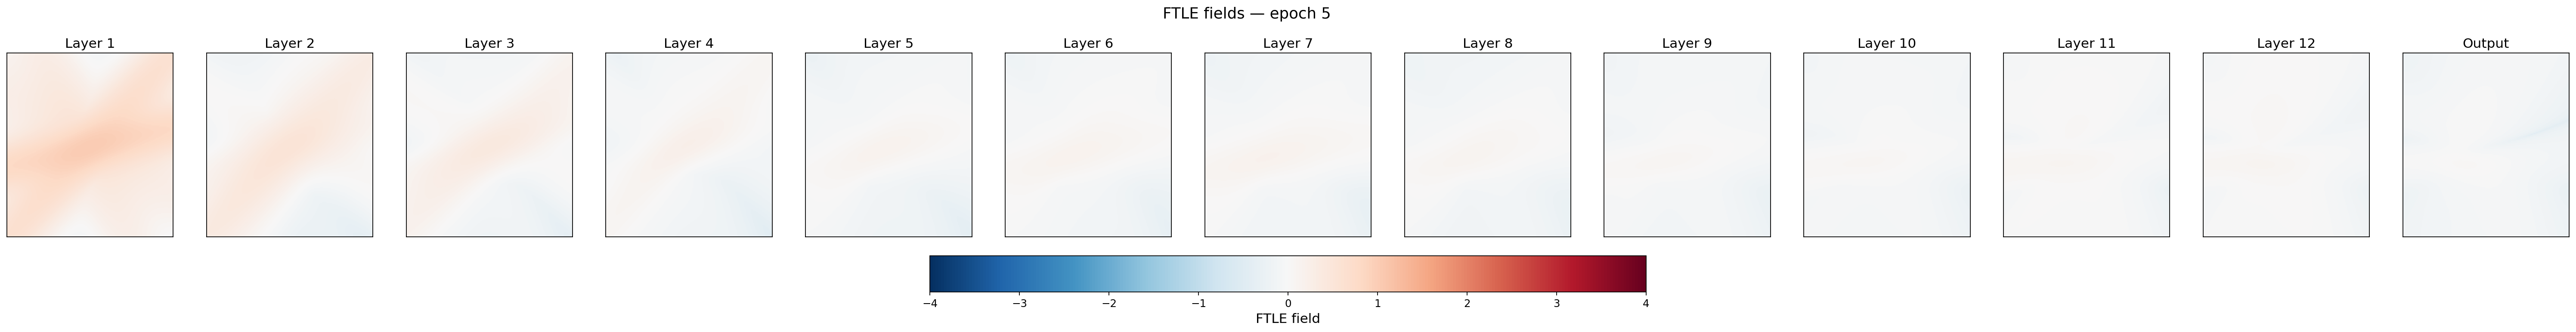

In [68]:
plot_ftle_fields_1x6(
    ftle_history,
    epoch_idx=0,         # first saved snapshot
    actual_epoch=5,      # if you saved every 5 epochs
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
)

In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import imageio.v2 as imageio


def make_ftle_gif_1x6(
    ftle_history,
    out_gif="ftle_evolution.gif",
    frames_dir="ftle_gif_frames",
    save_every=5,                 # FTLE computed every 5 epochs
    start_epoch=None,             # usually 5 if first snapshot is after epoch 5
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    cmap="RdBu_r",
    vmin=-3.0,
    vcenter=0.0,
    vmax=3.0,
    figsize=(48, 4.5),
    dpi=160,
    duration=0.8,                 # seconds per frame
):
    """
    Build a GIF from ftle_history with 6 panels:
    layer-1 ... layer-5, output
    """
    os.makedirs(frames_dir, exist_ok=True)

    layer_keys = [f"layer-{i+1}" for i in range(12)] + ["output"]
    n_frames = len(ftle_history[layer_keys[0]])

    if start_epoch is None:
        start_epoch = save_every

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    frame_paths = []

    for t in range(n_frames):
        fig, axes = plt.subplots(
            1, 13,
            figsize=figsize,
            dpi=dpi,
            # constrained_layout=True
        )

        im = None

        for i, key in enumerate(layer_keys):
            ax = axes[i]
            field = np.asarray(ftle_history[key][t])

            if field.ndim == 1:
                field = field.reshape(ny, nx)

            im = ax.imshow(
                field,
                extent=extent,
                origin="lower",
                cmap=cmap,
                norm=norm,
                aspect="auto",
            )

            if key != "output":
                k = int(key.split("-")[-1])
                ax.set_title(f"Layer {k}", fontsize=14)
            else:
                ax.set_title("Output", fontsize=14)

            ax.set_xticks([])
            ax.set_yticks([])

        cbar = fig.colorbar(
            im,
            ax=axes.ravel().tolist(),
            orientation="horizontal",
            location="bottom",
            shrink=0.8,
            pad=0.08,
        )
        cbar.set_label(r"FTLE field", fontsize=14)
        cbar.ax.tick_params(labelsize=11)

        epoch_num = start_epoch + t * save_every
        fig.suptitle(f"FTLE fields — epoch {epoch_num}", fontsize=16, y=1.03)

        frame_path = os.path.join(frames_dir, f"frame_{t:04d}.png")
        fig.savefig(frame_path, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

    # Build GIF
    images = [imageio.imread(p) for p in frame_paths]
    imageio.mimsave(out_gif, images, duration=duration)

    return out_gif, frame_paths

In [71]:
gif_path, frame_paths = make_ftle_gif_1x6(
    ftle_history,
    out_gif=f"experiment_{experiment_name}/10x12/circle_tanh_ftle_layers.gif",
    frames_dir=f"experiment_{experiment_name}/10x12/circle_tanh_ftle_frames",
    save_every=5,
    start_epoch=5,
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    vmin=-2,
    vcenter=0,
    vmax=2,
    duration=0.7,
)

print(gif_path)

experiment_8-ftle-per-epoch/10x12/circle_tanh_ftle_layers.gif
